# Анализ лояльности пользователей Яндекс Афиши

In [ ]:
#Установка зависимостей
!pip install -r requirements.txt

# 1. Загрузка данных и их предобработка

## Задача 1.1  

Требуется написать SQL-запрос, выгружающий в датафрейм pandas необходимые данные из базы данных `data-analyst-afisha`:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа;
- `order_ts` — дата и время создания заказа;
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

In [ ]:
# Импорты
from dotenv import load_dotenv
import os

from sqlalchemy import create_engine

import pandas as pd
import numpy as np

import phik

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Глобальная конфигурация
mpl.rcParams['figure.constrained_layout.use'] = True

In [ ]:
# Чтение .env файла
load_dotenv(dotenv_path='.env')

In [ ]:
# Подключение к бд
engine = create_engine(os.getenv('DB_CONNECTION_STRING'))

In [ ]:
# Получение данных
query = '''
SELECT
  user_id,
  device_type_canonical,
  order_id,
  created_dt_msk AS order_dt,
  created_ts_msk AS order_ts,
  currency_code,
  revenue,
  tickets_count,
  created_dt_msk::date - LAG(created_dt_msk::date) OVER (
    PARTITION BY user_id
    ORDER BY created_dt_msk
  ) AS days_since_prev,
  event_id,
  service_name,
  event_type_main,
  r.region_name,
  c.city_name
FROM afisha.purchases
LEFT JOIN afisha.events e USING (event_id)
LEFT JOIN afisha.city c USING (city_id)
LEFT JOIN afisha.regions r USING (region_id)
WHERE device_type_canonical IN ('mobile', 'desktop')
  AND event_type_main != 'фильм'
ORDER BY user_id
'''
df = pd.read_sql_query(query, con=engine)

In [ ]:
df


## Задача 1.2

Изучить общую информацию о выгруженных данных. Оценить корректность выгрузки и объём полученных данных.

Предположить, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксировать основную информацию о данных в кратком промежуточном выводе.

In [ ]:
# Размерность
df.shape

In [ ]:
# Пропуски
df.isna().sum()

In [ ]:
# Проверка типов
df.info()

### Промежуточный вывод

Данные корректно получены из базы данных. Строк: 290611, колонок: 14

Пропуски найдены только в столбце `days_since_prev` - это ожидаемое поведение

Требуются следующие корректировки типов данных:
- Столбец days_since_prev привести к int
- Downcast числовых столбцов для уменьшения затрат памяти

# 2. Предобработка данных

## Задача 2.1

Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Требуется привести выручку к единой валюте — российскому рублю.

Для этого можно использовать датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохранить в новый столбец `revenue_rub`.

In [ ]:
tenge_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv', parse_dates=['data'])
tenge_rate = tenge_rate.set_index('data')

In [ ]:
tenge_rate

In [ ]:
df['revenue_rub'] = df.apply(
    lambda row:
        row['revenue']
        if row['currency_code'] == 'rub'
        else row['revenue'] * tenge_rate.loc[row['order_dt']]['curs'] / tenge_rate.loc[row['order_dt']]['nominal'],
    axis=1
)

In [ ]:
df

## Задача 2.2

### 2.2.1 Проверить на пропущенные значения

In [ ]:
df.isna().sum()

Пропуски найдены только в столбце `days_since_prev` - это ожидаемое поведение

### 2.2.2 Преобразовать типы данных

In [ ]:
# Столбец days_since_prev привести к int
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'])

# Downcast числовых столбцов для уменьшения затрат памяти
for col in df.columns:
	if pd.api.types.is_integer_dtype(df[col]):
		df[col] = pd.to_numeric(df[col], downcast='integer')
	elif pd.api.types.is_float_dtype(df[col]):
		df[col] = pd.to_numeric(df[col], downcast='float')

In [ ]:
df.info()

### 2.2.3 Изучить значения в ключевых столбцах

In [ ]:
df['service_name'].value_counts()

In [ ]:
df['event_type_main'].value_counts()

In [ ]:
df['region_name'].value_counts()

In [ ]:
df['city_name'].value_counts()

Не найдено категорий, которые обозначают пропуски или отсутствие данных

In [ ]:
# Проверка уникальных значений в каждом столбце
df.nunique()

Аномалий с дубликатами в отдельных столбцах не выявлено. В order_id все значения уникальны и их количество соответствует количеству строк в данных. Следовательно, явные дубликаты в данных отсутствуют

Попробуем найти неявные дубликаты по другим комбинациям столбцов

In [ ]:
duplicate_checks = [
    ['user_id', 'event_id', 'order_ts'],
    ['user_id', 'event_id', 'order_ts', 'revenue', 'tickets_count', 'currency_code']
]

for cols in duplicate_checks:
    print(cols, ':')
    print(df.duplicated(subset=cols, keep='first').sum())
    print('---')

Есть 120 дубликатов по комбинации столбцов `'user_id', 'event_id', 'order_ts'`. Можно предположить, что часть их них получилась из-за особенностей системы заказов. Например, из-за разбиения билетов по отдельным заказам или из-за обработки системой очереди заказов пачками

Поэтому уточним столбцы для поиска дубликатов до набора `'user_id', 'event_id', 'order_ts', 'revenue', 'tickets_count', 'currency_code'`. Тогда получается 44 дубликата, в которых повторяется все, кроме id заказа. Эти дубликаты удалим из набора данных

В реальной задаче в подобной ситуации перед удалением стоит уточнить у отдела, работающего с бд, о природе подобных дубликатов

In [ ]:
# Удаление дубликатов
df_len = len(df)
print(f'Строк до удаления {df_len}')
df = df.drop_duplicates(subset=['user_id', 'event_id', 'order_ts', 'revenue', 'tickets_count', 'currency_code'], keep='first')
print(f'Строк после удаления {len(df)}. Удалено строк: {df_len - len(df)}')

Изучим разброс выручки заказов

In [ ]:
df['revenue_rub'].describe()

In [ ]:
# Построение графиков с разбросом выручки заказа
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Разброс выручки заказа')

sns.histplot(df['revenue_rub'], ax=axes[0])
axes[0].set(xlabel='Выручка', ylabel='Количество')
sns.boxplot(df['revenue_rub'], ax=axes[1])
axes[1].set(xlabel='', ylabel='Выручка')

plt.show()

In [ ]:
# Считаем маску для удаления из данных строк с `revenue_rub` больше 99 перцентиля + удаление отрицательных значений
# Применим после построения графиков
df_revenue_rub_99_mask = (
    (df['revenue_rub'] < df['revenue_rub'].quantile(.99))
    & (df['revenue_rub'] >= 0)
)

In [ ]:
revenue_rub_more_99_percentile = (~df_revenue_rub_99_mask).sum()

print(
    f"Всего заказов: {len(df)}, "
    f"заказов с выручкой ≥ 99-го перцентиля: {revenue_rub_more_99_percentile}, "
    f"доля: {revenue_rub_more_99_percentile / len(df):.2%}"
)

In [ ]:
# Построение графиков с разбросом выручки заказа без выбросов
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Разброс выручки заказа без выбросов')

revenue_rub_99 = df[df_revenue_rub_99_mask]['revenue_rub']

sns.histplot(revenue_rub_99, ax=axes[0])
axes[0].set(xlabel='Выручка', ylabel='Количество')
sns.boxplot(revenue_rub_99, ax=axes[1])
axes[1].set(xlabel='', ylabel='Выручка')

plt.show()

Даже без учета выбросов графики показывают правостороннюю асимметрию распределения выручки.

- Большинство заказов имеют небольшую стоимость (примерно 200–300 рублей).
- При этом наблюдается небольшой процент заказов с высокой выручкой (более 2000 рублей), формирующий длинный правый хвост распределения.

Такое распределение является типичным для данных о покупках билетов, где стоимость заказа может существенно различаться в зависимости от события и количества билетов.

Для более наглядного анализа формы распределения построим график распределения логарифма выручки.

In [ ]:
#Построение графика логарифма выручки
fig, ax = plt.subplots(figsize=(12, 6))

fig.suptitle('Разброс логарифма выручки заказа без выбросов')

revenue_rub_99_log = np.log1p(revenue_rub_99)

sns.histplot(revenue_rub_99_log, ax=ax)
ax.set(xlabel='Логарифм выручки', ylabel='Количество')

plt.show()

После логарифмирования стало заметно, что значительное количество заказов имеет нулевую выручку (log1p(0) = 0), что проявляется отдельным высоким столбцом в точке 0.

Теперь проведем анализ количества билетов в заказе (`tickets_count`).

In [ ]:
df['tickets_count'].describe()

In [ ]:
# Построение графиков с разбросом количества билетов в заказе
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('Разброс количества билетов')

sns.barplot(df.groupby('tickets_count').size(), ax=axes[0])
axes[0].set(xlabel='Количество билетов', ylabel='Количество заказов')
sns.boxplot(df['tickets_count'], ax=axes[1])
axes[1].set(ylabel='Количество билетов')

plt.show()

Построению графиков и анализу данных мешают заказы с большим количеством билетов. Посмотрим на количество таких заказов

In [ ]:
df.groupby('tickets_count').size().sort_index(ascending=False)

In [ ]:
# Количество заказов с количеством билетов больше 99 перцентилю
tickets_count_amount_more_99_percentile = (df['tickets_count'] >= df['tickets_count'].quantile(.99)).sum()

print(
    f"Всего заказов: {len(df)}, "
    f"заказов с количеством билетов ≥ 99-го перцентиля: {tickets_count_amount_more_99_percentile}, "
    f"доля: {tickets_count_amount_more_99_percentile / len(df):.2%}"
)


Заказы с количеством билетов выше 99-го перцентиля составляют около 1.54% от всех заказов, что соответствует ожидаемой доле для верхнего хвоста распределения. Эти наблюдения представляют редкие случаи крупных покупок билетов.

Уберем также данные по 99 перцентилю. Отрицательного количества билетов в заказах не выявлено

In [ ]:
# Считаем маску для удаления из данных строк с `tickets_count` больше 99 перцентиля
# Применим после построения графиков
df_tickets_count_99_mask = (df['tickets_count'] < df['tickets_count'].quantile(.99))

In [ ]:
# Построение графиков с разбросом количества билетов в заказе без выбросов
fig, axes = plt.subplots(figsize=(6, 6))

fig.suptitle('Разброс количества билетов без выбросов')

df_tickets_count_99 = df[df_tickets_count_99_mask]

sns.barplot(df_tickets_count_99.groupby('tickets_count').size(), ax=axes)
axes.set(xlabel='Количество билетов', ylabel='Количество заказов')

plt.show()

Большинство заказов — 2–3 билета. С ростом количества билетов число заказов уменьшается; покупки 5 билетов встречаются редко. Это указывает на то, что пользователи чаще всего покупают билеты для себя или небольшой компании.

Дополнительно проанализируем корреляцию между количеством билетов в заказе и его итоговой стоимостью:

In [ ]:
p = sns.jointplot(
    data=df,
    x='tickets_count',
    y='revenue_rub',
    kind='scatter',
    marginal_kws=dict(bins=30, fill=True),
)
p.set_axis_labels('Количество билетов', 'Выручка')
plt.show()

Заметной зависимости между количеством билетов в заказе и итоговой выручкой не наблюдается. Большинство заказов содержит небольшое количество билетов (1–4) с относительно низкой стоимостью.

Высокая выручка в отдельных заказах обусловлена, вероятно, высокой ценой билетов на конкретные мероприятия, а не большим количеством билетов.

При этом заказы с наибольшим количеством билетов имеют нулевую или почти нулевую стоимость, что может указывать на бесплатные мероприятия, на которые оформлялись групповые заказы.

Очистим данные от выбросов:

In [ ]:
df_len_before_cleaning = len(df)
print(f'Количество строк до удаления: {df_len_before_cleaning}')

df = df[df_revenue_rub_99_mask & df_tickets_count_99_mask]

df_len_after_cleaning = len(df)

print(
    f'Количество строк после удаления: {df_len_after_cleaning} '
    f'(удалено: {df_len_before_cleaning - df_len_after_cleaning}, '
    f'доля удалённых: {(df_len_before_cleaning - df_len_after_cleaning) / df_len_before_cleaning:.2%})'
)

### Промежуточный вывод

1. Добавлен столбец `revenue_rub` - стоимость заказа, приведённая к российскому рублю.
2. Пропуски найдены только в столбце `days_since_prev` - это ожидаемое поведение
3. Типы данных преобразованы к корректным и более оптимальным
4. Удалено 44 строки с неявными дубликатами
5. Явной сильной зависимости между стоимостью заказа и количеством билетов не выявлено
6. Удалено 4470 строк с выбросами по стоимости заказа или количеству билетов.

# 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

## Задача 3.1

Построить профиль пользователя — для каждого пользователя найти:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используя поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавить два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

In [ ]:
profiles = df.sort_values('order_ts').groupby('user_id').agg(
                order_dt_first=('order_dt', 'first'),
                order_dt_last=('order_dt', 'last'),
                first_device=('device_type_canonical', 'first'),
                first_region=('region_name', 'first'),
                first_service_name=('service_name', 'first'),
                first_event_type=('event_type_main', 'first'),
                orders_amount=('order_id', 'size'),
                mean_revenue_rub=('revenue_rub', 'mean'),
                mean_tickets_count=('tickets_count', 'mean'),
                mean_days_between_orders=('days_since_prev', 'mean'),
                is_two=('order_id', lambda orders: len(orders) >= 2),
                is_five=('order_id', lambda orders: len(orders) >= 5),
            )

## Задача 3.2

Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными происходит работа: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, требуется рассчитать:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также требуется изучить статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оценим данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Найти и оценить аномальные значения:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если будет проведена фильтрация, то вычислить объём отфильтрованных данных и вывести статистические показатели по обновлённому датасету.

In [ ]:
# Расчет показателей
print(
    f'Общее число пользователей в выборке: {len(profiles)}',
    f'\nСредняя выручка с одного заказа: {profiles.mean_revenue_rub.mean().round(2)}',
    f'\nДоля пользователей, совершивших 2 и более заказа: {profiles.is_two.mean() / 100:.4%}',
    f'\nДоля пользователей, совершивших 5 и более заказов: {profiles.is_five.mean() / 100:.4%}',
)

In [ ]:
# Статистические показатели
profiles[['orders_amount', 'mean_tickets_count', 'mean_days_between_orders']].describe()

In [ ]:
# Статистические показатели (Графики)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

sns.boxplot(profiles['orders_amount'], ax=axes[0])
axes[0].set(ylabel='', title='Количество заказов')

sns.boxplot(profiles['mean_tickets_count'], ax=axes[1])
axes[1].set(ylabel='', title='Количество билетов в заказе')

sns.boxplot(profiles['mean_days_between_orders'], ax=axes[2])
axes[2].set(ylabel='', title='Количество дней между заказами')

fig.set_constrained_layout_pads(wspace=0.15)
plt.show()

In [ ]:
orders_amount_q99 = profiles['orders_amount'].quantile(.99)
users_99 = (profiles['orders_amount'] >= orders_amount_q99).sum()

print(
    f'99-й перцентиль количества заказов: {orders_amount_q99}\n'
    f'Пользователей с количеством заказов ≥ 99-го перцентиля: {users_99}'
)

orders_amount_q95 = profiles['orders_amount'].quantile(.95)
users_95 = (profiles['orders_amount'] >= orders_amount_q95).sum()

print(
    f'95-й перцентиль количества заказов: {orders_amount_q95}\n'
    f'Пользователей с количеством заказов ≥ 99-го перцентиля: {users_95}'
)

**Оценка данных**

- Количество пользователей в выборке: 21 689. Этого достаточно для проведения анализа.

- В данных о количестве заказов выявлены аномальные значения. Максимальное количество заказов у пользователя составляет 9959. 99-й перцентиль количества заказов равен 150, а 95-й перцентиль - 31. Значение 150 заказов можно считать реалистичным для активного пользователя сервиса, поэтому для дальнейшего анализа данные будут ограничены 99-м перцентилем.

- В данных о количестве билетов в заказе аномалии не обнаружены, так как заказы с большим числом билетов были отфильтрованы на предыдущем этапе.

In [ ]:
# Фильтрация количества заказов по 99 перцентилю
profiles_len_before_cleaning = len(profiles)
print(f'Количество строк до удаления: {profiles_len_before_cleaning}')

profiles = profiles[profiles.orders_amount < orders_amount_q99]

profiles_len_after_cleaning = len(profiles)

print(
    f'Количество строк после удаления: {profiles_len_after_cleaning} '
    f'(удалено: {profiles_len_before_cleaning - profiles_len_after_cleaning}, '
    f'доля удалённых: {(profiles_len_before_cleaning - profiles_len_after_cleaning) / profiles_len_before_cleaning:.2%})'
)

In [ ]:
# Статистические показатели по обновленному датасету
profiles[['orders_amount', 'mean_tickets_count', 'mean_days_between_orders']].describe()

In [ ]:
# Гистограмма количества заказов
sns.histplot(x=profiles['orders_amount'], bins=50)
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')
plt.show()

### Промежуточный вывод

- Построены профили каждого пользователя

- Отфильтровано: 218 профилей, доля удалённых: 1.01%. После фильтрации выбросов по 99-му перцентилю правый хвост распределения стал значительно короче. Стандартное отклонение количества заказов снизилось примерно со 119 до 14.

# 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.

## Задача 4.1.1

Изучить распределение пользователей по признакам.

- Сгруппировать пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитать общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответить на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

In [ ]:
# Функции для подсчета и визуализации групп

def group_users(profiles: pd.DataFrame, column: str) -> pd.DataFrame:
    return (profiles.groupby(column)
        .size()
        .to_frame('count')
        .assign(share=lambda x: x['count'] / len(profiles))
        .sort_values('share', ascending=False)
    )

def plot_group_users(profiles: pd.DataFrame, column: str):
    groups = group_users(profiles, column)
    
    if len(groups) > 10:
        groups = pd.concat([
            groups.iloc[0:9],
            pd.DataFrame({
                'count': groups['count'][10:].sum(),
                'share': groups['share'][10:].sum(),
            }, index=['Остальные'])
        ])

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 10),
        gridspec_kw={'width_ratios': [1, 2]}
    )

    fig.suptitle(f'Распределение пользователей по {column}')

    if len(groups) > 5:
        sns.barplot(data=groups, ax=axes[0], x='count', y=groups.index)
    else:
        sns.barplot(data=groups['count'], ax=axes[0])
    axes[0].grid(True)

    groups.plot(
        kind='pie',
        y='share',
        autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
        ax=axes[1],
        startangle=90,
        legend=False,
    )

    return axes


In [ ]:
# Распределение по группам
segment_cols = ['first_event_type', 'first_device', 'first_region', 'first_service_name']

for col in segment_cols:
    plot_group_users(profiles, col)
    plt.show()

### Промежуточный вывод

В каждой группе есть явные "точки входа":

- По типу их первого мероприятия: Концерты
- По типу устройства, с которого совершена первая покупка: Мобильный телефон
- По региону проведения мероприятия из первого заказа: Каменевский регион и Североярская область
- По билетному оператору, продавшему билеты на первый заказ: "Билеты без проблем"

## Задача 4.1.2 Проанализировать возвраты пользователей:

- Для каждого сегмента вычислить долю пользователей, совершивших два и более заказа.
- Визуализировать результат подходящим графиком. Если сегментов слишком много, то поместить на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответить на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов требуется учитывать размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

Поэтому будем учитывать только сегменты с количеством пользователей не меньше 100

In [ ]:
# Функции для подсчета и визуализации групп
def group_users(profiles: pd.DataFrame, column: str) -> pd.DataFrame:
    return profiles.groupby(column).agg(
        users_count=('orders_amount', 'size'),
        share=('orders_amount', lambda x: (x >= 2).mean()),
    ).sort_values('share', ascending=False)

def plot_group_users(profiles: pd.DataFrame, column: str):
    groups = group_users(profiles, column)
    groups = groups[groups['users_count'] >= 100].head(10)

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(f'Доля пользователей, совершивших два и более заказа в группе {column}')

    sns.barplot(groups, legend=False, x='share', y=groups.index)

    ax.set_xlabel('Доля пользователей')
    ax.set_ylabel(column)
    ax.grid(True)

    # подписи с размером сегмента
    for i, row in groups.iterrows():
        ax.text(
            .05,
            i,
            f"Количество пользователей={row['users_count']}",
            va='center',
            color='white',
        )

    plt.show()


In [ ]:
# Распределение по группам
segment_cols = ['first_event_type', 'first_device', 'first_region', 'first_service_name']

for col in segment_cols:
    plot_group_users(profiles, col)

Перед выводом, обратим внимание, что среди сегментов

### Промежуточный вывод

- Сегменты с самым частым возвратом пользователей:
    - Тип мероприятия (first_event_type): выставки, театр
    - Устройство (first_device): компьютер немного опередил телефон
    - Регион (first_region): Горицветская область, Шанырский регион
    - Сервис (first_service_name): Show_ticket, Дом культуры, Край билетов
- Ярко выраженные "точки входа" не выявлены

## Задача 4.1.3

Опираясь на выводы из задач выше, проверить продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

In [ ]:
# Гипотеза 1
sport_return_rate = ((profiles['first_event_type'] == 'спорт') & profiles['is_two']).mean()
concert_return_rate = ((profiles['first_event_type'] == 'концерты') & profiles['is_two']).mean()

compare = "спорт" if sport_return_rate > concert_return_rate else "концерты" if concert_return_rate > sport_return_rate else "равны"

print(f"Доля возвратов спорт: {sport_return_rate:.4f}, Доля возвратов концерты: {concert_return_rate:.4f}. Больше возвратов у: {compare}")


**Вывод по гипотезе 1:** Гипотеза о том, что пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются чаще, чем пользователи с первым заказом на концерты, не подтвердилась. Наоборот, возврат среди пользователей, выбравших концерты, значительно выше.

In [ ]:
# Гипотеза 2
profile_groups = profiles.reset_index().groupby('first_region').agg(
    users_count=('user_id', 'size'),
    return_rate=('is_two', 'mean'),
).sort_values('users_count', ascending=False).head(25)

# Нормализация значений для удобства построения графика
# Теперь количество пользователей в регионе равняется числу в промежутке от 0 до 1
profile_groups['users_count'] /= profile_groups['users_count'].max()

plot_df = (
    profile_groups.reset_index()
    .rename(
        columns={
            'users_count': 'Нормализованное число пользователей',
            'return_rate': 'Доля пользователей с 2 и более заказами'
        }
    )
    .melt(
        id_vars='first_region',
        var_name='Метрики',
        value_name='value'
    )
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 8),
)

sns.barplot(
    data=plot_df,
    y='first_region',
    x='value',
    hue='Метрики',
    ax=axes[0],
    orient='h',
)
axes[0].set(xlabel='Регион', ylabel='Метрики')
axes[0].tick_params(axis='x', rotation=45)

sns.regplot(
    data=profile_groups,
    x='users_count',
    y='return_rate',
    ax=axes[1]
)
axes[1].set(xlabel='Количество пользователей в регионе', ylabel='Доля пользователей с 2+ заказами')

plt.show()

**Вывод по гипотезе 2**: Гипотеза о том, что в регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах, не подтвердилась. Есть очень слабая зависимость, но фактически отсутствует

### Промежуточный вывод

Гипотезы не подтвердились

## 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучить количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

### Задача 4.2.1

Проследить связь между средней выручкой сервиса с заказа и повторными заказами.

- Построить сравнительные гистограммы распределения средней выручки с билета (`mean_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответить на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

In [ ]:
# Построение графиков
profiles_1_order = profiles[~profiles['is_two']]
profiles_2_orders = profiles[profiles['is_two']]

plt.figure(figsize=(8, 5))

sns.histplot(
    profiles_1_order['mean_revenue_rub'],
    bins=30,
    alpha=0.5,
    label='Пользователи с 1 заказом',
    stat='density',
    kde=True
)

sns.histplot(
    profiles_2_orders['mean_revenue_rub'],
    bins=30,
    alpha=0.5,
    label='Пользователи с 2+ заказами',
    stat='density',
    kde=True
)

plt.xlabel('Средний чек пользователя')
plt.ylabel('Количество пользователей')
plt.title('Распределение среднего чека пользователей')

plt.legend(title='Группа пользователей')
plt.show()


### Промежуточный вывод

Пользователи с 1 заказом: концентрируются в диапазоне 0–500 рублей. Ярко выражен столбец с нулевой и около нулевой стоимостью.

Пользователи с 2+ заказами: концентрируются в диапазоне 250–750 рублей. Нет ярко выраженного столбца с нулевой стоимостью.

Различия между группами: распределение среднего чека у пользователей с 2+ заказами смещено вправо — их средний чек в целом выше, а доля пользователей с очень низким средним чеком значительно меньше.

## Задача 4.2.2

Сравнить распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответить на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

In [ ]:
# Построение графиков
profiles_2_4_orders = profiles[profiles['is_two'] & ~profiles['is_five']]
profiles_5_orders = profiles[profiles['is_five']]

plt.figure(figsize=(8, 5))

sns.histplot(
    profiles_2_4_orders['mean_revenue_rub'],
    bins=30,
    alpha=0.5,
    label='Пользователи с 2-4 заказами',
    stat='density',
    kde=True
)

sns.histplot(
    profiles_5_orders['mean_revenue_rub'],
    bins=30,
    alpha=0.5,
    label='Пользователи с 5+ заказами',
    stat='density',
    kde=True
)

plt.xlabel('Средний чек пользователя')
plt.ylabel('Количество пользователей')
plt.title('Распределение среднего чека пользователей')

plt.legend(title='Группа пользователей')
plt.show()


### Промежуточный вывод

Пользователи с 2–4 заказами: в основном сосредоточены в диапазоне 0–500 рублей. Распределение сильнее смещено к низким значениям среднего чека, заметна доля пользователей с очень низким чеком.

Пользователи с 5+ заказами: в основном сосредоточены в диапазоне 250–750 рублей. Пик распределения приходится примерно на 500 рублей, а доля пользователей с очень низким средним чеком ниже.

Различия между группами: распределение у пользователей с 5+ заказами смещено вправо относительно группы с 2–4 заказами, что указывает на более высокий средний чек у более активных пользователей.

## Задача 4.2.3

Проанализировать влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучить распределение пользователей по среднему количеству билетов в заказе (`mean_tickets_count`) и описать основные наблюдения.
- Разделить пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитать общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответить на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

In [ ]:
profiles.mean_tickets_count.describe()

In [ ]:
sns.histplot(
    profiles.mean_tickets_count,
    binwidth=0.5
)
plt.xlabel('Среднее количество билетов')
plt.ylabel('Число пользователей')
plt.show()

В среднем пользователи покупают от 2 до 3 билетов в рамках одного заказа

In [ ]:
# Разбиение на группы
ticket_groups = pd.cut(
    profiles['mean_tickets_count'],
    bins=[1,2,3,5,float('inf')],
    labels=[
        '1–2 билета',
        '2–3 билета',
        '3–5 билетов',
        '5+ билетов'
    ],
    include_lowest=True,
)

p_group_by_tickets = (profiles
    .assign(ticket_group=ticket_groups)
    .groupby('ticket_group').agg(
        count=('is_two', 'size'),
        count_is_two=('is_two', 'mean')
    )
)

p_group_by_tickets

In [ ]:
# Визуализация групп
sns.barplot(
    p_group_by_tickets['count'],
)

for i in range(len(p_group_by_tickets)):
    plt.gca().text(
        i-0.15,
        2000,
        p_group_by_tickets.iloc[i]['count_is_two'].round(3),
        va='center',
        color='white',
    )

plt.xlabel('Среднее количество билетов (На столбцах доля вернувшихся клиентов)')
plt.ylabel('Число пользователей')

plt.show()

### Промежуточный вывод

Сегменты распределены неравномерно: большинство пользователей покупают 2–3 билета за заказ

В этом же сегменте наблюдается самая высокая доля повторных покупок (~0.75)

Пользователи, покупающие 1–2 билета, возвращаются реже (~0.48)

В сегменте 3–5 билетов доля повторных заказов ниже, чем у 2–3 (~0.60)

Сегмент 5+ билетов отсутствует в данных

## 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучить временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

### Задача 4.3.1

Проанализировать, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделить день недели.
- Для каждого дня недели подсчитать общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализировать
.
- Ответить на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

In [139]:
# Построение групп
weekday_en_to_ru = {
    'Monday': 'Понедельник', 'Tuesday': 'Вторник', 'Wednesday': 'Среда',
    'Thursday': 'Четверг', 'Friday': 'Пятница', 'Saturday': 'Суббота', 'Sunday': 'Воскресенье'
}
profile_by_weekdays = (
    profiles.groupby(profiles['order_dt_first'].dt.day_name().map(weekday_en_to_ru))
    .agg(count=('is_two', 'size'), share=('is_two', 'mean'))
    .reindex([
        'Понедельник', 'Вторник', 'Среда', 'Четверг',
        'Пятница', 'Суббота', 'Воскресенье'
    ])
)

profile_by_weekdays

,count,share
order_dt_first,,
Понедельник,2890,0.624913
Вторник,3143,0.617881
Среда,3051,0.623074
Четверг,3099,0.594708
Пятница,3236,0.596106
Суббота,3301,0.627386
Воскресенье,2751,0.601236


In [ ]:
profile_by_weekdays.describe()

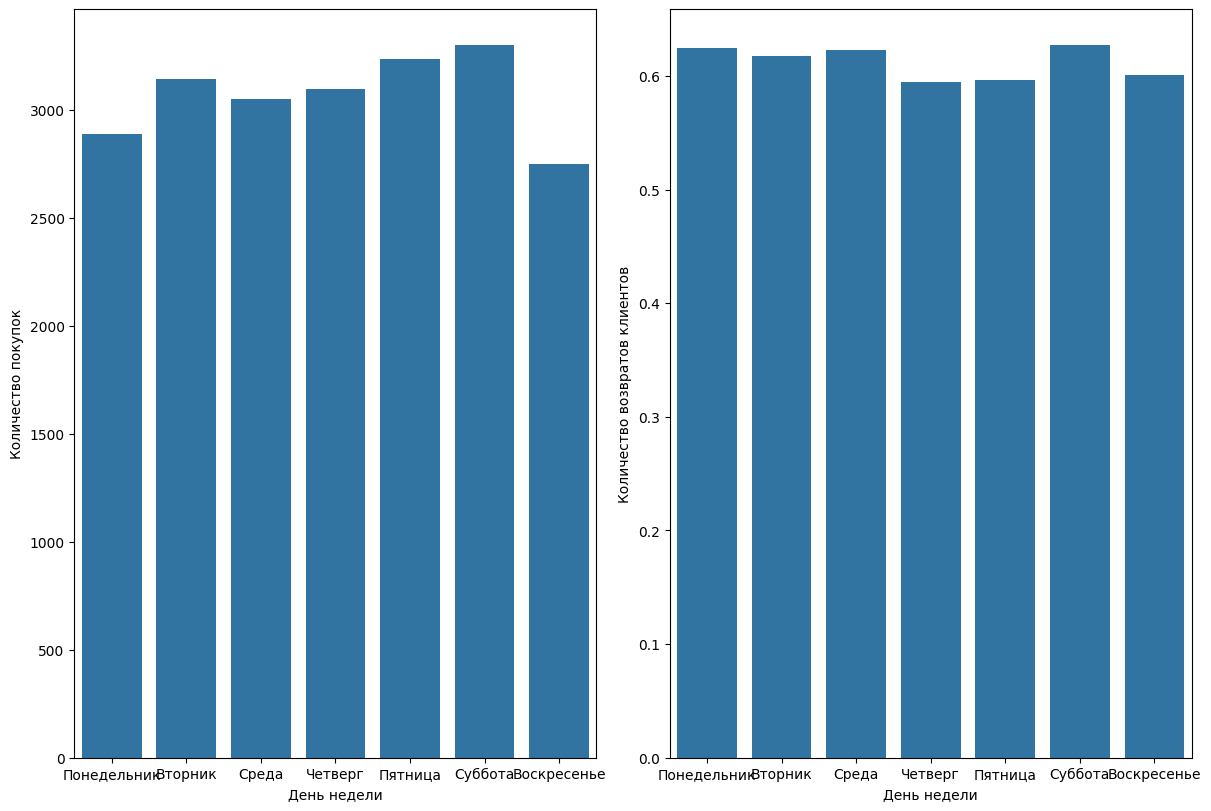

In [140]:
# Визуализация групп
fix, axes = plt.subplots(1,2,
    figsize=(12, 8),
)
sns.barplot(profile_by_weekdays['count'], ax=axes[0])
axes[0].set(xlabel='День недели', ylabel='Количество покупок')
sns.barplot(profile_by_weekdays['share'], ax=axes[1])
axes[1].set(xlabel='День недели', ylabel='Количество возвратов клиентов')
plt.show()

### Промежуточный вывод

- День недели практически не влияет на вероятность возврата клиента. Доля пользователей с повторными заказами находится в диапазоне от 0.595 до 0.63, что указывает на незначительные различия между днями недели.

- При этом день недели влияет на количество покупок билетов. Воскресенье (2751) и понедельник (2890) - наименее активные дни по числу заказов, тогда как пятница (3236) и суббота (3301) - наиболее активные дни покупки билетов.


## Задача 4.3.2

Изучить, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитать среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследовать, как средний интервал между заказами влияет на вероятность повторного заказа, и сделать выводы.


In [ ]:
# Построение групп
profile_orders_amount_groups = pd.cut(
    profiles[profiles['orders_amount'] >= 2]['orders_amount'],
    bins=[2,5,float('inf')],
    labels=[
        '2–4 заказа',
        '5+ заказов'
    ],
    include_lowest=True,
    right=False,
)

profile_days_between_orders_by_orders_amount = (
    profiles[profiles['orders_amount'] >= 2]
    .groupby(profile_orders_amount_groups).agg(
        days_between_orders=('mean_days_between_orders', 'mean'),
    )
)

profile_days_between_orders_by_orders_amount

In [ ]:
# Визуализация групп
sns.barplot(profile_days_between_orders_by_orders_amount['days_between_orders'])
plt.xlabel('Среднее время между заказами')
plt.ylabel('Количество дней между заказами')
plt.show()

### Промежуточный вывод

- Среднее время между заказами:
    - 2–4 заказа: 21 день
    - 5+ заказов: 10 дней
- Пользователи, совершившие 5 и более заказов, делают покупки существенно чаще - средний интервал между их заказами примерно в два раза меньше.
- Это может свидетельствовать о том, что более короткий интервал между покупками связан с более высокой активностью и удержанием пользователей: клиенты, которые возвращаются быстрее, со временем совершают больше заказов.

## 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучить, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого нужно использовать универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

### Задача 4.4.1

Провести корреляционный анализ:

- Рассчитать коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`orders_amount`). При необходимости можно использовать параметр `interval_cols` для определения интервальных данных.
- Проанализировать полученные результаты. Если полученные значения будут близки к нулю, проверить разброс данных в `orders_amount`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, нужно выделить сегменты пользователей по полю `orders_amount`, а затем повторить корреляционный анализ. Выделить такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализировать результат корреляции с помощью тепловой карты.
- Ответить на вопрос: какие признаки наиболее связаны с количеством заказов?

In [ ]:
# Подсчет корреляции
corr = (
    profiles
    .drop(columns=['is_two', 'is_five']) # Эти столбцы дублируют информацию о количестве заказов, их нет смысла анализировать
    .phik_matrix(
        interval_cols=['orders_amount', 'mean_revenue_rub', 'mean_tickets_count', 'mean_days_between_orders']
    )
    .loc['orders_amount']
    .drop('orders_amount')
    .sort_values(ascending=False)
    .to_frame()
)

In [ ]:
corr

In [ ]:
corr['phik_strength'] = pd.cut(
    corr['orders_amount'],
    bins=[0, 0.00001, 0.1, 0.3, 0.5, 0.7, 0.9, 1],
    labels=[
        'Нет связи',
        'Очень слабая',
        'Слабая',
        'Умеренная',
        'Сильная',
        'Очень сильная',
        'Почти полная'
    ],
    include_lowest=True
)

print('Коэфициенты корреляции:')
corr

Получены значения далекие от нуля, сегментация данных для анализа не требуется

In [ ]:
sns.heatmap(corr['orders_amount'].to_frame(), annot=True)

### Промежуточный вывод

Выявлена умеренная корреляция средней цены заказов пользователя с:
- Датой первого заказа
- Датой последнего заказа
- Средним количеством билетов в заказе

Выявлена слабая корреляция средней цены заказов пользователя со:
 - Средним числом дней между заказами
 - Средней стоимостью заказов
 - Регионом пользователя

# 5. Общий вывод и рекомендации

### Загрузка данных и предобработка
- Данные корректно выгружены из БД `data-analyst-afisha`: 290 611 строк, 14 столбцов. Учтены только заказы с устройств mobile/desktop, исключены мероприятия типа «фильм».
- Пропуски есть только в `days_since_prev` (ожидаемо для первого заказа). На этапе загрузки зафиксирована необходимость приведения типов и оптимизации памяти.

### Предобработка данных
- **Валюта:** добавлен столбец `revenue_rub` — выручка в рублях; тенге переведены по курсу на дату заказа.
- **Качество:** удалено 44 полных дубликата по набору полей заказа; типы данных приведены к корректным и сжаты (downcast).
- **Выбросы:** отфильтрованы заказы с выручкой или числом билетов выше 99-го перцентиля (в сумме удалено 4 470 строк). Распределение выручки правоскошенное; большинство заказов — 2–3 билета, 0–500 руб.

### Профиль пользователя
- Построены агрегаты по пользователям со всей необходимой для анализа информацией.
- В выборке **21 471 пользователь** (после отсечения по 99-му перцентилю числа заказов — удалено 218 профилей). Доля с 2+ заказами и 5+ заказами подсчитана; по числу заказов, среднему чеку и среднему числу билетов рассчитаны описательные статистики. Аномалии по числу заказов устранены ограничением по 99-му перцентилю.

### Распределение и возвраты по сегментам
- **«Точки входа»:** по первому заказу преобладают категории «Концерты» (тип мероприятия), mobile (устройство), Каменевский регион и Североярская область, оператор «Билеты без проблем».
- **Возвраты по сегментам (доля с 2+ заказами):** выше у выставок и театра; у desktop чуть выше, чем у mobile; среди регионов выделяются Горицветская область и Шанырский регион; среди операторов — Show_ticket, Дом культуры, Край билетов. Явных «точек входа» с аномально высокой долей возвратов не выявлено.
- **Гипотезы:** гипотеза «спорт возвращает чаще концертов» не подтвердилась (концерты дают выше долю возвратов); гипотеза о большей доле возвратов в самых активных регионах не подтвердилась — связь количества пользователей региона с долей возвратов практически отсутствует.

### Выручка и состав заказа
- **Средний чек и возврат:** у пользователей с 2+ заказами распределение среднего чека смещено вправо (250–750 руб.) по сравнению с одноразовыми (0–500 руб., много нулевых и околонулевых). Более высокая средняя выручка с заказа связана с большей вероятностью повторных покупок.
- **2–4 vs 5+ заказов:** у пользователей с 5+ заказами средний чек выше (пик около 500 руб.), чем у группы 2–4 заказа.
- **Число билетов:** большинство пользователей в сегменте 2–3 билета; в нём же максимальная доля повторных покупок (~0,75). Сегмент 1–2 билета возвращается реже (~0,40); 3–5 билетов — промежуточный (~0,60). Сегмент 5+ билетов в данных после фильтрации отсутствует.

### Временные характеристики
- **День недели первого заказа:** почти не влияет на вероятность возврата (доли возвратов 0,595–0,63). Объём первых покупок выше в пятницу и субботу, ниже в воскресенье и понедельник.
- **Интервал между заказами:** у пользователей с 2–4 заказами средний интервал ~21 день, с 5+ заказами ~10 дней. Более частые покупки связаны с большим числом заказов и лучшим удержанием.

### Корреляционный анализ (phi_k)
- С числом заказов наиболее связаны: дата первого заказа, дата последнего заказа, среднее число билетов в заказе (умеренная связь); слабее — средний интервал между заказами, средняя выручка, регион. Тип устройства, оператор и тип мероприятия первого заказа дают очень слабую связь с числом заказов.

---

## Краткое резюме для заказчика

**О данных:** Использованы заказы Яндекс Афиши (mobile/desktop, без фильмов). Выручка приведена к рублям, удалены дубликаты и выбросы по выручке и числу билетов (99-й перцентиль); профили с экстремальным числом заказов отсечены по 99-му перцентилю. Итоговая выборка — **21 471 пользователь**.

**Основные метрики:** подсчитаны доля пользователей с 2+ и 5+ заказами, распределение по числу заказов, средний чек, среднее число билетов и средний интервал между заказами.

**Признаки возврата:** выше возвращаемость у пользователей с более высоким средним чеком и с 2–3 билетами в заказе; по сегментам — выставки, театр, desktop, отдельные регионы и операторы. День недели первого заказа на возврат почти не влияет; короткий средний интервал между заказами связан с большим числом заказов.

**Корреляции с числом заказов:** сильнее всего связаны даты первого/последнего заказа, среднее число билетов, средний интервал между заказами и средняя выручка; признаки первого заказа (устройство, тип мероприятия, оператор) — слабо.

---

## Рекомендации

1. **Фокус на удержании после первого заказа:** сегменты с высокой долей возвратов (выставки, театр; регионы вроде Горицветской области и Шанырского; операторы Show_ticket, Дом культуры, Край билетов) использовать как ориентир для коммуникаций и формата первого опыта, не забывая про размер сегментов при интерпретации.
2. **Повышение среднего чека и «корзины»:** пользователи с более высоким средним чеком и 2–3 билетами в заказе чаще возвращаются — имеет смысл тестировать предложения «второй билет дешевле», групповые скидки и напоминания о мероприятиях с высоким средним чеком.
3. **Работа с одноразовыми и низким чеком:** пользователи с одним заказом и низким/нулевым чеком — группа риска; для них целесообразны персонализированные рассылки, скидки на вторую покупку и упор на форматы с большей вовлечённостью (выставки, театр).
4. **Ритм покупок:** более частые покупатели (короткий средний интервал) делают больше заказов — стоит тестировать напоминания и акции по истечении типичного интервала (порядка 2–3 недель) после последнего заказа.
5. **Не опираться на день недели первого заказа** для прогноза возврата; пики по пятнице–субботе учитывать для загрузки и коммуникаций.
6. **Модель прогноза возврата:** в качестве ориентира приоритетно использовать средний чек, среднее число билетов, средний интервал между заказами, даты первого/последнего заказа и регион; тип устройства, оператор и тип мероприятия первого заказа — как вспомогательные.

Проект загружен на гитхаб https://github.com/Daniel217D/Yandex-afisha-data-analysis